# 5. Apprentissage Supervisé - Analyse de Sentiment

Ce notebook implémente plusieurs modèles de classification de sentiment sur des avis d'assurance :
1. TF-IDF + Régression Logistique
2. TF-IDF + SVM (LinearSVC)
3. Réseau de neurones avec Embedding layer (Keras)
4. Embeddings pré-entraînés Word2Vec (Keras)
5. BERT fine-tuné (HuggingFace)
6. LLM Zero-shot (facebook/bart-large-mnli)

Objectif : Classer les avis en **négatif**, **neutre**, **positif** à partir des étoiles.

In [2]:
import time
import warnings
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import torch
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping
from tensorflow.keras.layers import (
    Embedding, GlobalAveragePooling1D, Dense, Dropout
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from torch.utils.data import Dataset as TorchDataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from transformers import pipeline as hf_pipeline

from app.utils.spinner import run_with_spinner
from config import *

In [3]:
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

In [4]:
if tf.test.gpu_device_name():
    print('GPU device found')
else:
    print("No GPU found")

GPU device found


2026-03-31 00:09:07.053684: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-03-31 00:09:07.053724: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-03-31 00:09:07.053731: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-03-31 00:09:07.053748: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-31 00:09:07.053763: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



## 5.1 Préparation des données

In [5]:
df = pd.read_csv(DATA_CLEAN)

In [6]:
label2id = {'négatif': 0, 'neutre': 1, 'positif': 2}
id2label = {v: k for k, v in label2id.items()}

In [7]:
df['label'] = df[SENTIMENT_COL].map(label2id)

In [8]:
df_model = df[df[CLEAN_COL].notna() & (df[CLEAN_COL].str.strip() != '')].copy()

In [9]:
X = df_model[CLEAN_COL].to_numpy(dtype=str)
y = df_model['label'].to_numpy(dtype=int)
results = {}

In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

In [11]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

In [12]:
print(f'Train : {len(X_train):,} | Val : {len(X_val):,} | Test : {len(X_test):,}')

Train : 16,869 | Val : 3,615 | Test : 3,615


## 5.2 Modèle 1 : TF-IDF + Régression Logistique

In [13]:
pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
param_grid_lr = {'clf__C': [0.1, 1, 10]}

In [14]:
gs_lr = GridSearchCV(
    pipeline_lr, param_grid_lr,
    cv=3, scoring='f1_macro', n_jobs=-1, verbose=0
)

t0 = time.time()
run_with_spinner(
    lambda: gs_lr.fit(X_train, y_train),
    msg='GridSearchCV TF-IDF + LR (C ∈ {0.1, 1, 10})...'
)
train_time_lr = time.time() - t0

print(f'Meilleur C : {gs_lr.best_params_["clf__C"]}  |  CV F1-macro : {gs_lr.best_score_:.4f}')
print(f'Temps d\'entraînement : {train_time_lr:.1f}s')

Meilleur C : 0.1  |  CV F1-macro : 0.6611
Temps d'entraînement : 6.6s


In [15]:
best_lr = gs_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='macro')
prec_lr = precision_score(y_test, y_pred_lr, average='macro', zero_division=0)
rec_lr = recall_score(y_test, y_pred_lr, average='macro', zero_division=0)

In [16]:
print(f'Accuracy  : {acc_lr:.4f}')
print(f'F1 macro  : {f1_lr:.4f}')
print(f'Précision : {prec_lr:.4f}')
print(f'Rappel    : {rec_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=list(label2id.keys())))

Accuracy  : 0.7804
F1 macro  : 0.6763
Précision : 0.6786
Rappel    : 0.6760

              precision    recall  f1-score   support

     négatif       0.85      0.91      0.88      1648
      neutre       0.31      0.33      0.32       507
     positif       0.88      0.80      0.83      1460

    accuracy                           0.78      3615
   macro avg       0.68      0.68      0.68      3615
weighted avg       0.79      0.78      0.78      3615



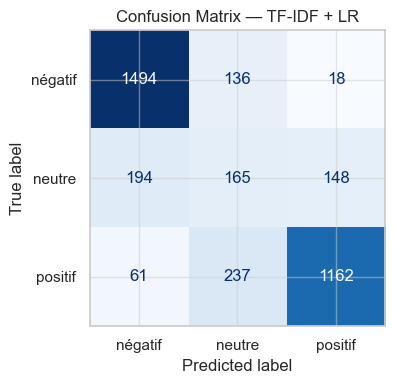

In [17]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=list(label2id.keys()))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — TF-IDF + LR')
plt.tight_layout()
plt.show()

In [18]:
joblib.dump(best_lr, str(TFIDF_LR_PATH))

['/Users/amaitre/prive/4_ECOLE/S8/NLP/sentiment_analysis_model/models/supervised/tfidf_lr.pkl']

In [19]:
results['TF-IDF + LR'] = {
    'Accuracy': acc_lr, 'F1_macro': f1_lr,
    'Precision': prec_lr, 'Recall': rec_lr,
    'Training_time': train_time_lr
}

## 5.3 Modèle 2 : TF-IDF + SVM (LinearSVC)

In [20]:
pipeline_svm = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf', LinearSVC(class_weight='balanced', max_iter=2000, random_state=42))
])

In [21]:
t0 = time.time()
run_with_spinner(
    lambda: pipeline_svm.fit(X_train, y_train),
    msg='Entraînement TF-IDF + SVM...'
)
train_time_svm = time.time() - t0
print(f'Temps d\'entraînement : {train_time_svm:.1f}s')

Temps d'entraînement : 0.7s


In [22]:
y_pred_svm = pipeline_svm.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm, average='macro')
prec_svm = precision_score(y_test, y_pred_svm, average='macro', zero_division=0)
rec_svm = recall_score(y_test, y_pred_svm, average='macro', zero_division=0)

In [23]:
print(f'Accuracy  : {acc_svm:.4f}')
print(f'F1 macro  : {f1_svm:.4f}')
print(f'Précision : {prec_svm:.4f}')
print(f'Rappel    : {rec_svm:.4f}')
print(classification_report(y_test, y_pred_svm, target_names=list(label2id.keys())))

Accuracy  : 0.7840
F1 macro  : 0.6458
Précision : 0.6483
Rappel    : 0.6486
              precision    recall  f1-score   support

     négatif       0.84      0.90      0.87      1648
      neutre       0.26      0.19      0.22       507
     positif       0.84      0.86      0.85      1460

    accuracy                           0.78      3615
   macro avg       0.65      0.65      0.65      3615
weighted avg       0.76      0.78      0.77      3615



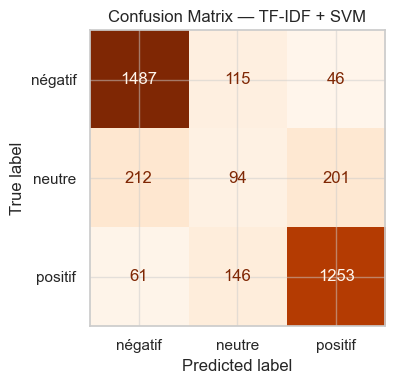

In [24]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=list(label2id.keys()))
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('Confusion Matrix — TF-IDF + SVM')
plt.tight_layout()
plt.show()

In [25]:
joblib.dump(pipeline_svm, str(TFIDF_SVM_PATH))

['/Users/amaitre/prive/4_ECOLE/S8/NLP/sentiment_analysis_model/models/supervised/tfidf_svm.pkl']

In [26]:
results['TF-IDF + SVM'] = {
    'Accuracy': acc_svm, 'F1_macro': f1_svm,
    'Precision': prec_svm, 'Recall': rec_svm,
    'Training_time': train_time_svm
}

## 5.4 Modèle 3 : Réseau de neurones avec Embedding layer (Keras)

In [27]:
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

In [28]:
NUM_WORDS = 20000
MAX_LEN = 200
EMBED_DIM = 128

In [29]:
tokenizer_keras = Tokenizer(num_words=NUM_WORDS, oov_token='<OOV>')
tokenizer_keras.fit_on_texts(X_train)

In [30]:
X_train_seq = pad_sequences(tokenizer_keras.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post',
                            truncating='post')
X_val_seq = pad_sequences(tokenizer_keras.texts_to_sequences(X_val), maxlen=MAX_LEN, padding='post',
                          truncating='post')
X_test_seq = pad_sequences(tokenizer_keras.texts_to_sequences(X_test), maxlen=MAX_LEN, padding='post',
                           truncating='post')

print(f'Shape train : {X_train_seq.shape} | val : {X_val_seq.shape} | test : {X_test_seq.shape}')

Shape train : (16869, 200) | val : (3615, 200) | test : (3615, 200)


In [31]:
tf.random.set_seed(42)

model_nn = Sequential([
    Embedding(NUM_WORDS, EMBED_DIM, input_length=MAX_LEN),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
], name='nn_embedding')

model_nn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_nn.summary()

2026-03-31 00:09:16.467252: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-31 00:09:16.467266: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "nn_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
tb_nn = TensorBoard(log_dir=str(LOG_DIR / 'nn_embedding'), histogram_freq=1)
es_nn = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [33]:
t0 = time.time()
history_nn = run_with_spinner(
    lambda: model_nn.fit(
        X_train_seq, y_train,
        epochs=10, batch_size=64,
        validation_data=(X_val_seq, y_val),
        callbacks=[tb_nn, es_nn],
        verbose=0
    ),
    msg='Entraînement NN Embedding...'
)
train_time_nn = time.time() - t0
print(f'Temps d\'entraînement : {train_time_nn:.1f}s')

Temps d'entraînement : 48.0s


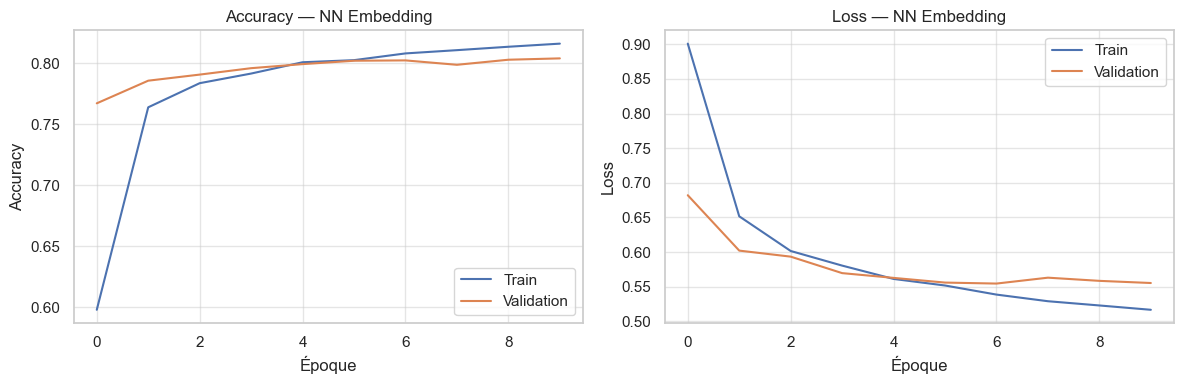

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_nn.history['accuracy'], label='Train')
axes[0].plot(history_nn.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy — NN Embedding')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_nn.history['loss'], label='Train')
axes[1].plot(history_nn.history['val_loss'], label='Validation')
axes[1].set_title('Loss — NN Embedding')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [35]:
y_pred_nn_prob = model_nn.predict(X_test_seq)
y_pred_nn = np.argmax(y_pred_nn_prob, axis=1)

acc_nn = accuracy_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn, average='macro')
prec_nn = precision_score(y_test, y_pred_nn, average='macro', zero_division=0)
rec_nn = recall_score(y_test, y_pred_nn, average='macro', zero_division=0)

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [36]:
print(f'Accuracy  : {acc_nn:.4f}')
print(f'F1 macro  : {f1_nn:.4f}')
print(f'Précision : {prec_nn:.4f}')
print(f'Rappel    : {rec_nn:.4f}')
print()
print(classification_report(y_test, y_pred_nn, target_names=list(label2id.keys())))

Accuracy  : 0.8163
F1 macro  : 0.5849
Précision : 0.5437
Rappel    : 0.6330

              precision    recall  f1-score   support

     négatif       0.83      0.95      0.89      1648
      neutre       0.00      0.00      0.00       507
     positif       0.80      0.95      0.87      1460

    accuracy                           0.82      3615
   macro avg       0.54      0.63      0.58      3615
weighted avg       0.70      0.82      0.75      3615



In [37]:
model_nn.save(str(NN_EMBEDDING_MODEL_PATH))

In [38]:
results['NN Embedding'] = {
    'Accuracy': acc_nn, 'F1_macro': f1_nn,
    'Precision': prec_nn, 'Recall': rec_nn,
    'Training_time': train_time_nn
}

## 5.5 Modèle 4 : Embeddings pré-entraînés Word2Vec (Keras)

In [39]:
w2v_model = Word2Vec.load(str(W2V_MODEL_PATH))
print(f'Word2Vec chargé. Vocabulaire : {len(w2v_model.wv):,} tokens, dim={w2v_model.vector_size}')

Word2Vec chargé. Vocabulaire : 6,790 tokens, dim=100


In [40]:
vocab_size = min(NUM_WORDS, len(tokenizer_keras.word_index) + 1)
w2v_dim = w2v_model.vector_size
embedding_matrix = np.zeros((vocab_size, w2v_dim))
hits, misses = 0, 0

In [41]:
for word, idx in tokenizer_keras.word_index.items():
    if idx >= vocab_size:
        continue
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
        hits += 1
    else:
        misses += 1

print(f'Tokens couverts : {hits:,} / Tokens manquants : {misses:,}')
print(f'Couverture : {hits / (hits + misses) * 100:.1f}%')

Tokens couverts : 6,751 / Tokens manquants : 5,875
Couverture : 53.5%


In [42]:
tf.random.set_seed(42)

model_w2v = Sequential([
    Embedding(
        vocab_size, w2v_dim,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    ),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
], name='nn_word2vec_frozen')

model_w2v.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_w2v.summary()

Model: "nn_word2vec_frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     1,262,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,262,700 (4.82 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,262,700 (4.82 MB)

In [43]:
tb_w2v = TensorBoard(log_dir=str(LOG_DIR / 'nn_word2vec'), histogram_freq=1)
es_w2v = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [44]:
t0 = time.time()

history_w2v = run_with_spinner(
    lambda: model_w2v.fit(
        X_train_seq, y_train,
        epochs=5, batch_size=64,
        validation_data=(X_val_seq, y_val),
        callbacks=[tb_w2v, es_w2v],
        verbose=0
    ),
    msg='Phase 1 : entraînement avec embeddings gelés...'
)

model_w2v.layers[0].trainable = True
model_w2v.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_w2v_ft = run_with_spinner(
    lambda: model_w2v.fit(
        X_train_seq, y_train,
        epochs=5, batch_size=64,
        validation_data=(X_val_seq, y_val),
        callbacks=[tb_w2v, es_w2v],
        verbose=0
    ),
    msg='Phase 2 : fine-tuning (embeddings dégelés)...'
)

train_time_w2v = time.time() - t0
print(f'Temps total : {train_time_w2v:.1f}s')

Temps total : 31.3s


In [45]:
acc_hist = history_w2v.history['accuracy'] + history_w2v_ft.history['accuracy']
vacc_hist = history_w2v.history['val_accuracy'] + history_w2v_ft.history['val_accuracy']
loss_hist = history_w2v.history['loss'] + history_w2v_ft.history['loss']
vloss_hist = history_w2v.history['val_loss'] + history_w2v_ft.history['val_loss']

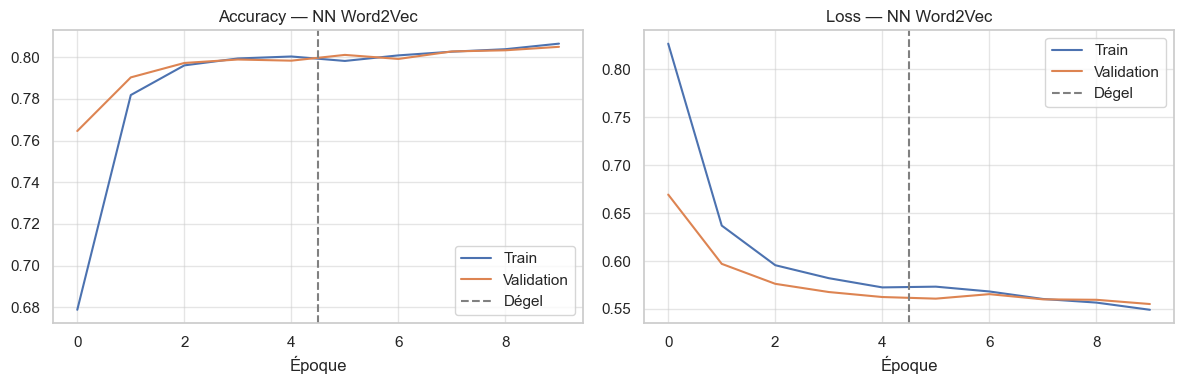

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(acc_hist, label='Train')
axes[0].plot(vacc_hist, label='Validation')
axes[0].axvline(len(history_w2v.history['accuracy']) - 0.5, color='gray', linestyle='--', label='Dégel')
axes[0].set_title('Accuracy — NN Word2Vec')
axes[0].set_xlabel('Époque')
axes[0].legend()

axes[1].plot(loss_hist, label='Train')
axes[1].plot(vloss_hist, label='Validation')
axes[1].axvline(len(history_w2v.history['loss']) - 0.5, color='gray', linestyle='--', label='Dégel')
axes[1].set_title('Loss — NN Word2Vec')
axes[1].set_xlabel('Époque')
axes[1].legend()

plt.tight_layout()
plt.show()

In [47]:
y_pred_nn_test = np.argmax(model_nn.predict(X_test_seq), axis=1)
y_pred_w2v_test = np.argmax(model_w2v.predict(X_test_seq), axis=1)

f1_nn_rand = f1_score(y_test, y_pred_nn_test, average='macro')
f1_nn_w2v = f1_score(y_test, y_pred_w2v_test, average='macro')
print(f'F1 macro — Embedding aléatoire : {f1_nn_rand:.4f}')
print(f'F1 macro — Word2Vec            : {f1_nn_w2v:.4f}')

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
F1 macro — Embedding aléatoire : 0.5849
F1 macro — Word2Vec            : 0.5880


In [48]:
acc_w2v = accuracy_score(y_test, y_pred_w2v_test)
f1_w2v = f1_score(y_test, y_pred_w2v_test, average='macro')
prec_w2v = precision_score(y_test, y_pred_w2v_test, average='macro', zero_division=0)
rec_w2v = recall_score(y_test, y_pred_w2v_test, average='macro', zero_division=0)

In [49]:
print(classification_report(y_test, y_pred_w2v_test, target_names=list(label2id.keys())))

              precision    recall  f1-score   support

     négatif       0.81      0.97      0.88      1648
      neutre       0.33      0.01      0.01       507
     positif       0.82      0.92      0.87      1460

    accuracy                           0.81      3615
   macro avg       0.66      0.63      0.59      3615
weighted avg       0.75      0.81      0.76      3615



In [50]:
model_w2v.save(str(NN_W2V_MODEL_PATH))

In [51]:
results['NN Word2Vec'] = {
    'Accuracy': acc_w2v, 'F1_macro': f1_w2v,
    'Precision': prec_w2v, 'Recall': rec_w2v,
    'Training_time': train_time_w2v
}

## 5.6 Modèle 5 : BERT fine-tuné (HuggingFace)

In [52]:
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'Device : {DEVICE}')

Device : mps


In [53]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN_BERT = 128
N_BERT = len(X_train) if DEVICE in ('cuda', 'mps') else 5000
print(f'Taille du jeu d\'entraînement BERT : {N_BERT:,}')

Taille du jeu d'entraînement BERT : 16,869


In [54]:
idx_sub = np.random.RandomState(42).choice(len(X_train), min(N_BERT, len(X_train)), replace=False)
X_bert_train, y_bert_train = X_train[idx_sub], y_train[idx_sub]

bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [55]:
class ReviewDataset(TorchDataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [56]:
train_dataset_bert = ReviewDataset(X_bert_train, y_bert_train, bert_tokenizer, MAX_LEN_BERT)
val_dataset_bert = ReviewDataset(X_val, y_val, bert_tokenizer, MAX_LEN_BERT)
test_dataset_bert = ReviewDataset(X_test, y_test, bert_tokenizer, MAX_LEN_BERT)
print(
    f'Datasets créés — Train : {len(train_dataset_bert)}, Val : {len(val_dataset_bert)}, Test : {len(test_dataset_bert)}')

Datasets créés — Train : 16869, Val : 3615, Test : 3615


In [57]:
if (BERT_DIR / 'model.safetensors').exists():
    print(f"Modèle BERT déjà entraîné — chargement depuis {BERT_DIR} (entraînement ~20 min ignoré).")
    bert_model = AutoModelForSequenceClassification.from_pretrained(str(BERT_DIR))
    print(f"Modèle chargé depuis {BERT_DIR}.")
else:
    bert_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=3
    )
    print(f'Modèle {MODEL_NAME} chargé ({sum(p.numel() for p in bert_model.parameters()):,} paramètres).')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modèle distilbert-base-uncased chargé (66,955,779 paramètres).


In [58]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro', zero_division=0)
    }

In [59]:
training_args = TrainingArguments(
    output_dir=str(BERT_DIR),
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_dir=str(LOG_DIR / 'bert'),
    logging_steps=50,
    seed=42,
    report_to='tensorboard',
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset_bert,
    eval_dataset=val_dataset_bert,
    compute_metrics=compute_metrics
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [60]:
if (BERT_DIR / 'model.safetensors').exists():
    train_time_bert = 0.0
    print("Entraînement ignoré (modèle déjà sauvegardé dans BERT_DIR).")
else:
    t0 = time.time()
    trainer.train()
    train_time_bert = time.time() - t0
    print(f'Temps d\'entraînement : {train_time_bert:.1f}s')

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.549369,0.566143,0.791701,0.581285
2,0.520529,0.545360,0.804149,0.609106
3,0.423331,0.545019,0.807746,0.659398


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Temps d'entraînement : 1293.0s


In [61]:
bert_preds_raw = trainer.predict(test_dataset_bert)
y_pred_bert = np.argmax(bert_preds_raw.predictions, axis=-1)

acc_bert = accuracy_score(y_test, y_pred_bert)
f1_bert = f1_score(y_test, y_pred_bert, average='macro')
prec_bert = precision_score(y_test, y_pred_bert, average='macro', zero_division=0)
rec_bert = recall_score(y_test, y_pred_bert, average='macro', zero_division=0)

In [62]:
print(f'Accuracy  : {acc_bert:.4f}')
print(f'F1 macro  : {f1_bert:.4f}')
print(f'Précision : {prec_bert:.4f}')
print(f'Rappel    : {rec_bert:.4f}')
print()
print(classification_report(y_test, y_pred_bert, target_names=list(label2id.keys())))

Accuracy  : 0.8136
F1 macro  : 0.6426
Précision : 0.6631
Rappel    : 0.6559

              precision    recall  f1-score   support

     négatif       0.86      0.93      0.89      1648
      neutre       0.31      0.11      0.16       507
     positif       0.82      0.92      0.87      1460

    accuracy                           0.81      3615
   macro avg       0.66      0.66      0.64      3615
weighted avg       0.77      0.81      0.78      3615



In [63]:
if not (BERT_DIR / 'model.safetensors').exists():
    bert_model.save_pretrained(str(BERT_DIR))
    bert_tokenizer.save_pretrained(str(BERT_DIR))
    print("Modèle et tokenizer sauvegardés.")
else:
    print("Sauvegarde ignorée (modèle déjà présent).")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modèle et tokenizer sauvegardés.


In [64]:
results['DistilBERT'] = {
    'Accuracy': acc_bert, 'F1_macro': f1_bert,
    'Precision': prec_bert, 'Recall': rec_bert,
    'Training_time': train_time_bert
}

## 5.7 Modèle 6 : LLM Zero-shot (facebook/bart-large-mnli)

In [65]:
N_ZS = 200  # Zero-shot est lent
np.random.seed(42)
idx_zs = np.random.choice(len(X_test), min(N_ZS, len(X_test)), replace=False)
X_zs = X_test[idx_zs]
y_zs = y_test[idx_zs]

In [66]:
# device : 0=CUDA, 'mps'=Apple GPU, -1=CPU
if DEVICE == 'cuda':
    zs_device = 0
elif DEVICE == 'mps':
    zs_device = 'mps'
else:
    zs_device = -1

In [67]:
print(f'Chargement du pipeline zero-shot (facebook/bart-large-mnli) sur device={zs_device}...')
zs_classifier = hf_pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=zs_device
)
print('Pipeline chargé.')

Chargement du pipeline zero-shot (facebook/bart-large-mnli) sur device=mps...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Pipeline chargé.


In [68]:
zs_labels_sentiment = ['positive review', 'neutral review', 'negative review']
label_map_zs = {
    'positive review': 2,  # positif
    'neutral review': 1,  # neutre
    'negative review': 0  # négatif
}

In [69]:
print(f'Inférence zero-shot sur {N_ZS} exemples...')
t0 = time.time()

zs_preds = []
for i, text in enumerate(X_zs):
    result = zs_classifier(str(text)[:512], candidate_labels=zs_labels_sentiment)
    best_label = result['labels'][0]
    zs_preds.append(label_map_zs[best_label])
    if (i + 1) % 50 == 0:
        print(f'  {i + 1}/{N_ZS} exemples traités...')

train_time_zs = time.time() - t0
print(f'Temps d\'inférence : {train_time_zs:.1f}s')

Inférence zero-shot sur 200 exemples...
  50/200 exemples traités...
  100/200 exemples traités...
  150/200 exemples traités...
  200/200 exemples traités...
Temps d'inférence : 42.3s


In [70]:
y_pred_zs = np.array(zs_preds)
acc_zs = accuracy_score(y_zs, y_pred_zs)
f1_zs = f1_score(y_zs, y_pred_zs, average='macro', zero_division=0)
prec_zs = precision_score(y_zs, y_pred_zs, average='macro', zero_division=0)
rec_zs = recall_score(y_zs, y_pred_zs, average='macro', zero_division=0)

In [71]:
print(f'Accuracy  : {acc_zs:.4f}')
print(f'F1 macro  : {f1_zs:.4f}')
print(f'Précision : {prec_zs:.4f}')
print(f'Rappel    : {rec_zs:.4f}')
print()
print(classification_report(y_zs, y_pred_zs, target_names=list(label2id.keys())))

Accuracy  : 0.7350
F1 macro  : 0.5672
Précision : 0.6056
Rappel    : 0.5861

              precision    recall  f1-score   support

     négatif       0.87      0.74      0.80        97
      neutre       0.29      0.08      0.12        25
     positif       0.66      0.94      0.78        78

    accuracy                           0.73       200
   macro avg       0.61      0.59      0.57       200
weighted avg       0.72      0.73      0.71       200



In [72]:
results['Zero-shot BART'] = {
    'Accuracy': acc_zs, 'F1_macro': f1_zs,
    'Precision': prec_zs, 'Recall': rec_zs,
    'Training_time': train_time_zs
}

## 5.8 Comparaison des modèles

In [73]:
df_results = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
df_results = df_results.sort_values('F1_macro', ascending=False)
display_cols = ['Model', 'Accuracy', 'F1_macro', 'Precision', 'Recall', 'Training_time']

In [74]:
print(df_results[display_cols].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

         Model  Accuracy  F1_macro  Precision  Recall  Training_time
   TF-IDF + LR    0.7804    0.6763     0.6786  0.6760         6.5635
  TF-IDF + SVM    0.7840    0.6458     0.6483  0.6486         0.7129
    DistilBERT    0.8136    0.6426     0.6631  0.6559      1293.0360
   NN Word2Vec    0.8149    0.5880     0.6557  0.6323        31.3376
  NN Embedding    0.8163    0.5849     0.5437  0.6330        47.9836
Zero-shot BART    0.7350    0.5672     0.6056  0.5861        42.2768


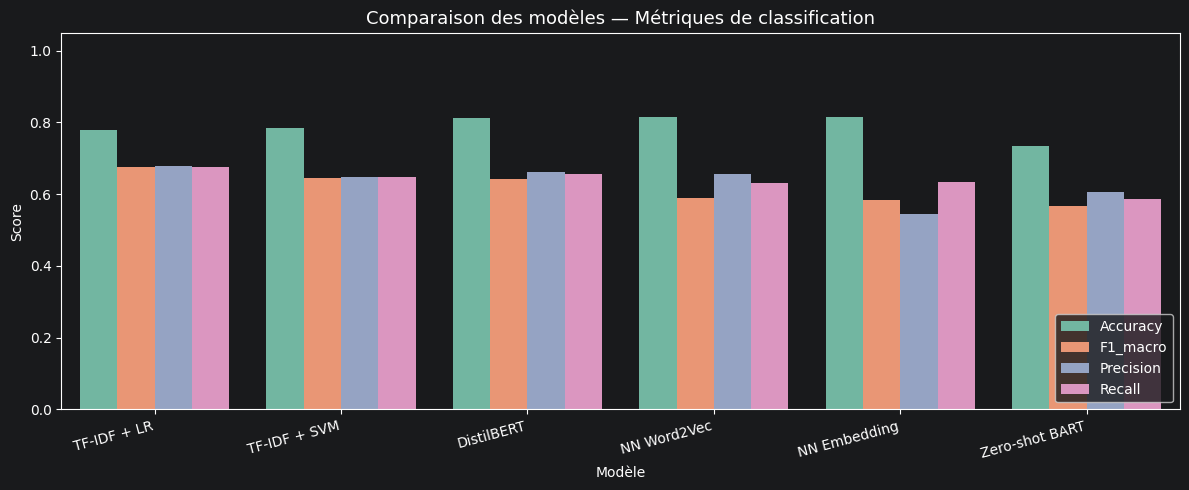

In [75]:
metrics_to_plot = ['Accuracy', 'F1_macro', 'Precision', 'Recall']
df_melt = df_results.melt(id_vars='Model', value_vars=metrics_to_plot,
                          var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=df_melt, x='Model', y='Score', hue='Metric',
    palette='Set2', ax=ax
)
ax.set_title('Comparaison des modèles — Métriques de classification', fontsize=13)
ax.set_xlabel('Modèle')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

In [76]:
best_model_name = df_results.iloc[0]['Model']
best_f1 = df_results.iloc[0]['F1_macro']
print(f'\nMeilleur modèle : {best_model_name} (F1 macro = {best_f1:.4f})')


Meilleur modèle : TF-IDF + LR (F1 macro = 0.6763)


## 5.9 Analyse des erreurs

In [77]:
sklearn_results = {k: v for k, v in results.items() if k in ['TF-IDF + LR', 'TF-IDF + SVM']}
best_sklearn = max(sklearn_results, key=lambda k: sklearn_results[k]['F1_macro'])
print(f'Modèle sklearn sélectionné pour l\'analyse : {best_sklearn}')

Modèle sklearn sélectionné pour l'analyse : TF-IDF + LR


In [78]:
best_model = best_lr if best_sklearn == 'TF-IDF + LR' else pipeline_svm
y_pred_best = best_model.predict(X_test)

In [79]:
df_errors = pd.DataFrame({
    'text': X_test,
    'true': [id2label[l] for l in y_test],
    'pred': [id2label[l] for l in y_pred_best],
    'true_id': y_test,
    'pred_id': y_pred_best
})
df_errors['correct'] = df_errors['true_id'] == df_errors['pred_id']
df_errors['length'] = df_errors['text'].apply(len)

In [80]:
wrong = df_errors[~df_errors['correct']]
print(f'Total erreurs : {len(wrong):,} / {len(df_errors):,} ({len(wrong) / len(df_errors) * 100:.1f}%)')

Total erreurs : 794 / 3,615 (22.0%)


In [81]:
# Faux positifs (prédit positif, vrai = autre)
fp = wrong[wrong['pred'] == 'positif'].head(10)

In [82]:
# Faux négatifs (prédit négatif, vrai = autre)
fn = wrong[wrong['pred'] == 'négatif'].head(10)

In [83]:
# Neutres mal classifiés
nm = wrong[wrong['true'] == 'neutre'].head(10)

In [84]:
print('10 Faux Positifs (prédit positif, vrai ≠ positif)')
for _, row in fp.iterrows():
    print(f'  [vrai={row["true"]}] {row["text"][:120]}')

10 Faux Positifs (prédit positif, vrai ≠ positif)
  [vrai=neutre] satisfait prix correct voir pub téler devis correct ensemble
  [vrai=neutre] satisfaire service conseillèr zen totalement satisfait dossier accepter organisme prêteur caisse épargne
  [vrai=neutre] satisfaire accueil service rendre appel olivier information clair bon disponibilité personne cordialement tousser
  [vrai=neutre] tarif correct attendre prise charge personnaliser client direct assurance
  [vrai=négatif] pas vraiment satisfait service euro an option kilomètr énorme probablement changement temps
  [vrai=neutre] simple pratique rapide personn sympathique agréable téléphone application facile utilisation
  [vrai=neutre] service client compétent conseiller prendre temps adapter donner information content trouver olivier malus an prix beauc
  [vrai=négatif] assurance restrictif garantie
  [vrai=neutre] bonjour personn agréable téléphone rapide question vite traiter conseiller connaître bien produit recommander serv

In [85]:
print('10 Faux Négatifs (prédit négatif, vrai ≠ négatif)')
for _, row in fn.iterrows():
    print(f'  [vrai={row["true"]}] {row["text"][:120]}')

10 Faux Négatifs (prédit négatif, vrai ≠ négatif)
  [vrai=neutre] souci contrat excelium mettre impossible faire moindre retrait contre dépôt aucun souci fois agent axa déplacer dire pro
  [vrai=neutre] client actuel auto habitation passer prestataire bris glace aucun problème prendre charge sans intervenir
  [vrai=positif] suite accrochage prendre charge rapidement téléphone conseil élément constat remplir pas oublier jusque réparation
  [vrai=positif] bonjour agréablement surprise début beaucoup hésitation commentaire négatif souscrire mar furet malheureusement déclarer
  [vrai=neutre] arrêt travail maladie avril actuellement reconnaître invalidité octobre dossier banqu faire fonctionner assurance prêt a
  [vrai=positif] assurer véhicule habitation aucun problème signaler sinistre traiter sans aucun problème
  [vrai=positif] maison entièrement brûler conseiller réactif compétent tard emménageai maison reconstruite vien besoin protection juridi
  [vrai=neutre] problème augmentation an

In [86]:
print('10 Neutres mal classifiés')
for _, row in nm.iterrows():
    print(f'  [prédit={row["pred"]}] {row["text"][:120]}')

10 Neutres mal classifiés
  [prédit=positif] satisfait prix correct voir pub téler devis correct ensemble
  [prédit=négatif] souci contrat excelium mettre impossible faire moindre retrait contre dépôt aucun souci fois agent axa déplacer dire pro
  [prédit=positif] satisfaire service conseillèr zen totalement satisfait dossier accepter organisme prêteur caisse épargne
  [prédit=négatif] client actuel auto habitation passer prestataire bris glace aucun problème prendre charge sans intervenir
  [prédit=positif] satisfaire accueil service rendre appel olivier information clair bon disponibilité personne cordialement tousser
  [prédit=positif] tarif correct attendre prise charge personnaliser client direct assurance
  [prédit=négatif] arrêt travail maladie avril actuellement reconnaître invalidité octobre dossier banqu faire fonctionner assurance prêt a
  [prédit=négatif] problème augmentation annuel décalage total rapport indice annuel moyen bout an intéressant changer assureur
  [prédit=n

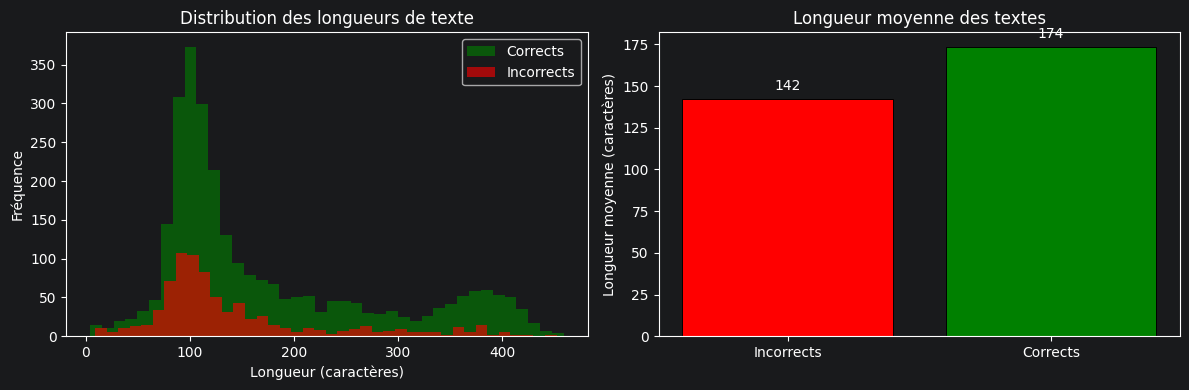

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_errors[df_errors['correct']]['length'], bins=40, alpha=0.6, label='Corrects', color='green')
axes[0].hist(df_errors[~df_errors['correct']]['length'], bins=40, alpha=0.6, label='Incorrects', color='red')
axes[0].set_title('Distribution des longueurs de texte')
axes[0].set_xlabel('Longueur (caractères)')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

length_stats = df_errors.groupby('correct')['length'].mean()
labels_bar = ['Incorrects', 'Corrects']
values_bar = [length_stats.get(False, 0), length_stats.get(True, 0)]
axes[1].bar(labels_bar, values_bar, color=['red', 'green'], edgecolor='black', linewidth=0.7)
axes[1].set_title('Longueur moyenne des textes')
axes[1].set_ylabel('Longueur moyenne (caractères)')
for i, v in enumerate(values_bar):
    axes[1].text(i, v + 5, f'{v:.0f}', ha='center')

plt.tight_layout()
plt.show()

In [88]:
error_words = Counter()
for text in wrong['text']:
    error_words.update(str(text).lower().split())

In [89]:
top_error_words = error_words.most_common(20)
words_e, counts_e = zip(*top_error_words) if top_error_words else ([], [])

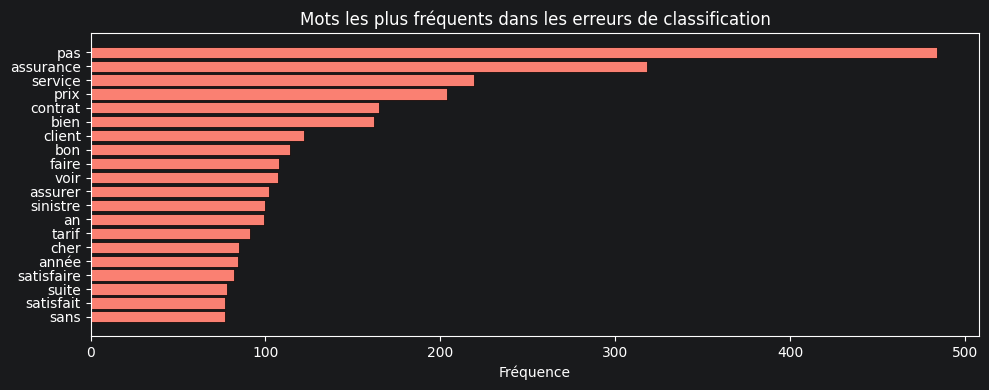

In [90]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(list(words_e)[::-1], list(counts_e)[::-1], color='salmon', edgecolor='black', linewidth=0.5)
ax.set_title('Mots les plus fréquents dans les erreurs de classification')
ax.set_xlabel('Fréquence')
plt.tight_layout()
plt.show()

In [91]:
models_cms = {
    'TF-IDF + LR': (y_pred_lr, 'Blues'),
    'TF-IDF + SVM': (y_pred_svm, 'Oranges'),
    'NN Embedding': (y_pred_nn, 'Greens'),
    'NN Word2Vec': (y_pred_w2v_test, 'Purples'),
    'DistilBERT': (y_pred_bert, 'Reds')
}

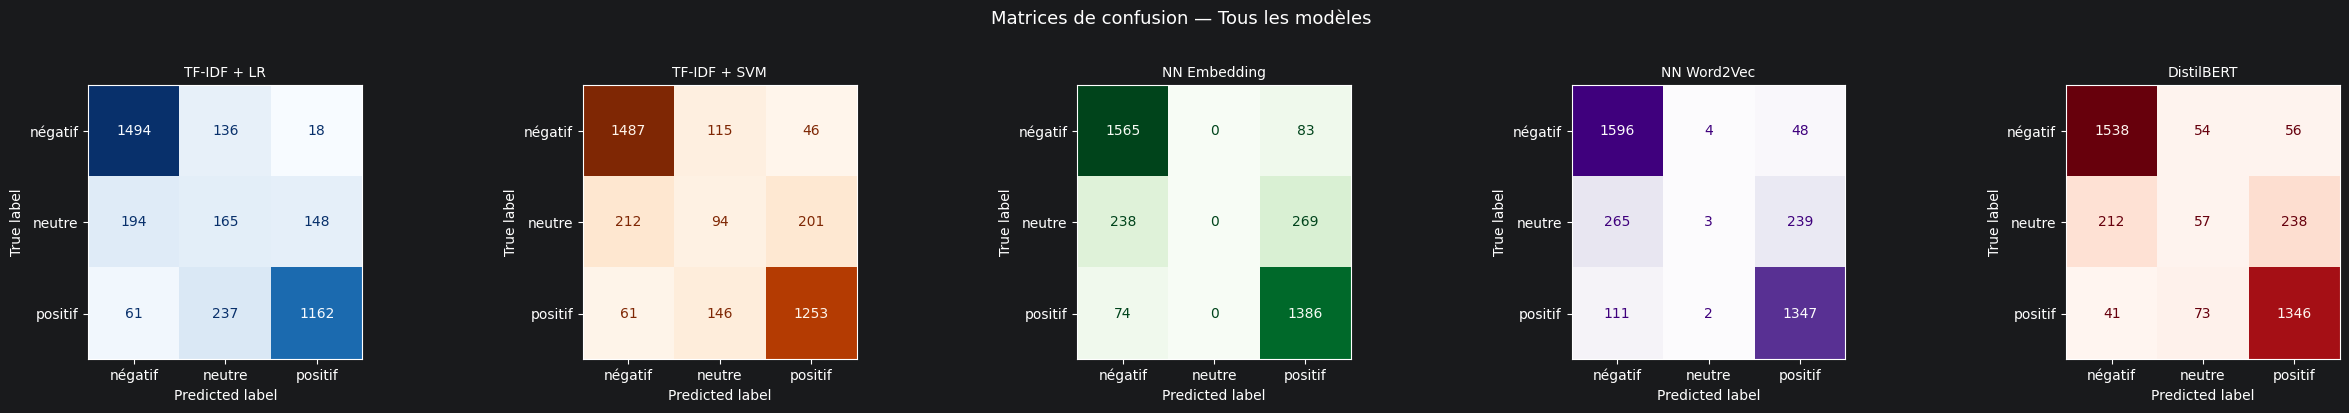

In [92]:
n_models = len(models_cms)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))

for ax, (name, (preds, cmap)) in zip(axes, models_cms.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(label2id.keys()))
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(name, fontsize=10)

plt.suptitle('Matrices de confusion — Tous les modèles', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Récapitulatif final

In [93]:
print(df_results[['Model', 'Accuracy', 'F1_macro', 'Training_time']].to_string(index=False,
                                                                                float_format=lambda x: f'{x:.4f}'))

         Model  Accuracy  F1_macro  Training_time
   TF-IDF + LR    0.7804    0.6763         6.5635
  TF-IDF + SVM    0.7840    0.6458         0.7129
    DistilBERT    0.8136    0.6426      1293.0360
   NN Word2Vec    0.8149    0.5880        31.3376
  NN Embedding    0.8163    0.5849        47.9836
Zero-shot BART    0.7350    0.5672        42.2768


In [94]:
print(f'Meilleur modèle : {df_results.iloc[0]["Model"]} (F1 macro = {df_results.iloc[0]["F1_macro"]:.4f})')

Meilleur modèle : TF-IDF + LR (F1 macro = 0.6763)
